# 📈 Time Series Forecasting: Sales Analysis & SARIMAX Modeling

This notebook demonstrates a comprehensive **Time Series Analysis** project, applying industry-standard principles to forecast sales data over a 729-day period. Our goal is to move beyond simple curve-fitting and build a statistically sound, "Signal-Focused" model that accounts for both internal cycles and external marketing impacts.

---

### 🧠 Core Time Series Principles Applied
To ensure the reliability of our forecast, this project adheres to the most common foundational principles:
* **Stationarity:** Testing for a constant mean and variance using the **ADF Test** to ensure the model doesn't drift.
* **Seasonality ($s=7$):** Identifying and modeling the rhythmic "weekly pulse" inherent in retail/sales data.
* **Autoregression & Moving Averages:** Using past values ($p$) and past errors ($q$) to inform future predictions.
* **Exogenous Impact:** Incorporating external drivers—specifically **Marketing Lags**—to understand how outside actions influence sales volume.

---

### 🔄 The Forecasting Workflow
We will navigate through the full Data Science lifecycle for time series, including:
1.  **Exploratory Data Analysis (EDA):** Visualizing trends and decomposing the series into Trend, Seasonal, and Residual components.
2.  **Statistical Testing:** Proving data stability via **Augmented Dickey-Fuller** critical values.
3.  **Model Identification:** Utilizing **ACF/PACF** plots to determine the optimal $(p, d, q)$ orders.
4.  **Training & Optimization:** Fitting a **SARIMAX$(1,1,1) \times (2,1,2,7)$** model.
5.  **Rigorous Validation:** * **In-Sample Evaluation:** Checking fit on historical data.
    * **Rolling-Origin Cross-Validation:** Testing stability across 5 different "future" folds.
    * **Residual Diagnostics:** Ensuring errors are random "White Noise" (Ljung-Box Test).
6.  **Future Forecasting:** Generating a **30-day forecast** with 95% Confidence Intervals to quantify business risk.

---

### 🛠️ Step 1: Environment Setup & Library Architecture

* **`pandas`, `numpy` & `matplotlib.pyplot`**: These form the core **Data Science & Visualization** foundation of the project, used for managing the 729-day dataset, performing vector calculations, and generating all diagnostic plots from historical trends to the final 30-day "probability cloud."
* **`seasonal_decompose`**: Used to break the sales data into its core components: the underlying **Trend**, the 7-day **Seasonality**, and the random **Residuals**.
* **`adfuller`**: Performs the Augmented Dickey-Fuller test to determine if the data is stationary by comparing the test statistic against **Critical Values**.
* **`grangercausalitytests`**: Used to statistically prove if our **Marketing** variables actually "cause" or lead to changes in sales volume.
* **`plot_acf` & `plot_pacf`**: Visualizes the "memory" of the data to help us mathematically select the optimal $p$ and $q$ lags for the model.
* **`SARIMAX`**: The core forecasting algorithm that integrates seasonal patterns $(P,D,Q,s)$ and external exogenous factors like marketing spend.
* **`acorr_ljungbox`**: A diagnostic tool used to ensure the model's errors are purely random ("White Noise") and contain no leftover patterns.
* **`mean_squared_error` & `mean_absolute_error`**: Used to calculate the **MAPE** and **RMSE** to quantify the model's accuracy during the 5-fold cross-validation.
---

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller,grangercausalitytests,acf,pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error,mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

### 📊 Step 2: Synthetic Data Generation & Feature Engineering

In this stage, we simulate a realistic 729-day retail environment. Rather than using simple random numbers, we "engineer" specific business behaviors into the dataset to test our model's ability to extract meaningful signals from complex noise.

* **`Time Indexing & Trend`**: We establish a continuous daily timeline from 2024 through 2025. A linear **Trend** is injected to represent long-term business growth, ensuring the model has a non-stationary baseline to account for.
* **`Multi-Level Seasonality`**: We apply trigonometric functions (Sine and Cosine waves) to simulate two distinct rhythms: a **7-day Weekly Cycle** (representing weekend shopping surges) and a **30.5-day Monthly Cycle** (simulating payday-related spending spikes).
* **`Exogenous Marketing Impact`**: We generate "Marketing Spend" using a Gamma distribution to create realistic, non-uniform pulses. Crucially, we apply a **2-day Shift**, acknowledging the real-world principle that marketing efforts typically have a delayed effect on actual sales.
* **`Dynamic Noise & Profit`**: To mirror real-world volatility, we add **Level-Dependent Noise**, where the "jaggedness" of the data increases as the sales volume grows. We also link a "Profit" metric to the underlying trend to provide a secondary variable for future correlation analysis.
* **`Visual Verification`**: The final **`sales`** column is assembled by summing these components, and a primary time-series plot is generated to confirm that the simulated patterns look like authentic retail behavior.

---

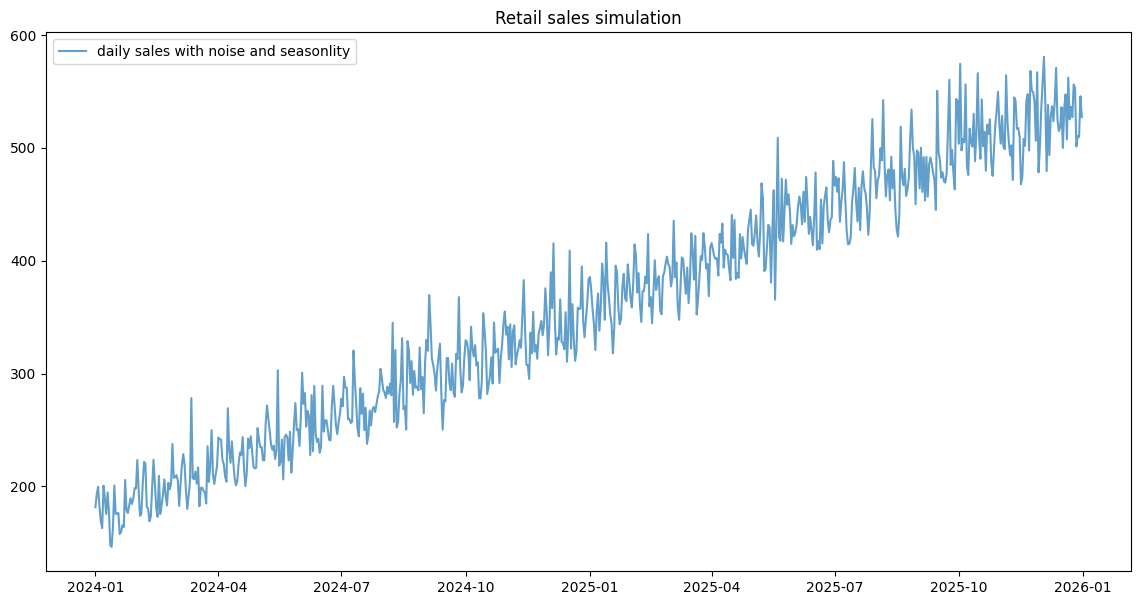

enhanced dataset created
            marketing_spend     profit       sales
2024-01-01        23.936794  19.703331  181.527549
2024-01-02        14.944647  21.780323  193.147462
2024-01-03        13.822836  21.948782  199.639364
2024-01-04        13.823023  18.703631  181.761816
2024-01-05        46.497144  19.590936  169.075225
2024-01-06        28.667062  16.811262  163.047757
2024-01-07        11.310780  19.390952  200.713965
2024-01-08        24.698145  17.415272  189.004352
2024-01-09        19.989603  24.539206  175.450947
2024-01-10         2.159149  20.826607  194.691171


In [25]:
#setup time index
np.random.seed(42)
date_range = pd.date_range(start = '2024-01-01',end = '2025-12-31',freq = 'D')
df = pd.DataFrame(index = date_range)
#get components of the dataset
n = len(df)
time = np.arange(n)
#set tredn
trend = 0.5 *time
#set week seasonlity with sine wave , spikes on weekends
weekly_seasonality = 12*np.sin(2*np.pi*time/7)
#monthly spikes payday spikes
monthly_seasonlaity = 8*np.cos(2*np.pi*time/30.5)
#marketing spend , just random pulses
df['marketing_spend'] = np.random.gamma(shape=2, scale= 10, size = n)
#profit linked with trend
df['profit'] = 20 +(0.15*trend) + np.random.normal(0,3,size = n)
# adding noise , as sales the swing on noise increase
level_dependent_noise = np.random.normal(0,1,size =n)*(1+0.05*trend)
#assemble sales
#marketing impact is delayed by two days
marketing_impact = df['marketing_spend'].shift(2).fillna(df['marketing_spend'].mean())*1.2
df['sales'] = 150+trend+weekly_seasonality+monthly_seasonlaity+marketing_impact+level_dependent_noise

plt.figure(figsize=(14,7))
plt.plot(df.index,df['sales'],label ='daily sales with noise and seasonlity',alpha = 0.7)
plt.title("Retail sales simulation")
plt.legend()
plt.show()
print("enhanced dataset created")
print(df.head(10))

### 🔍 Step 3: Temporal Integrity & Frequency Validation

The mathematical foundation of any **SARIMAX** model relies on a perfectly continuous timeline. This cell performs a rigorous "Data Audit" to ensure our 729-day series is structurally sound. **Purpose:** Verify that the dataset possesses a proper datetime index with a consistent frequency, as irregular intervals (missing days or uneven spacing) can invalidate the model's ability to calculate seasonal patterns and autoregressive lags.

* **`Index Authentication`**: We confirm the index is a **`DatetimeIndex`** rather than a standard integer or string. This "date-awareness" is a mechanical requirement for Python's time series libraries to perform time-based slicing and resampling.
* **`Frequency Detection`**: We use **`inferred_freq`** to ensure the dataset is recognized as having a 'D' (Daily) frequency. A result of `None` would indicate irregular intervals, which would require interpolation before modeling.
* **`Gap & Interval Audit`**: By analyzing the **`unique_diffs`**, we verify that the distance between every single observation is exactly 1 day. Multiple unique intervals would signal "holes" in our history that could lead to biased forecasts.
* **`Range Reconstruction`**: We generate a theoretical **`expected_range`** and compare it against our actual data. This "Missing Dates Check" acts as the final gatekeeper, ensuring our 729 actual days perfectly match the 729 expected days in the 2024-2025 calendar.

---

In [26]:
print("\nIndex Check : ")
print(f"index type : {type(df.index)}")
print(f"is datetimeindex : {isinstance(df.index,pd.DatetimeIndex)}") # this code check if index is datetime
# time series analysis requires datetime-aware indes not integer / string

print("\nFrequency Detections : ")
print(f"Frequency : {df.index.inferred_freq}") # the expected value here should be 'D'
# this created daily intervals , if Non it means irregular intervals

print("\nGap Detection : ") # gap between each observation
unique_diffs = date_diffs.dropna().unique()
print(f"Number of different invtervals : {len(unique_diffs)}") # should be 1 , multiple value means irregular spacing

print("\nMissing Dates Checks : ")
expected_range = pd.date_range(start = df.index.min(),end = df.index.max(),freq = "D")
missing_dates = expected_range.difference(df.index )
print(f"Expected number of days : {len(expected_range)}")
print(f"Actual number of days : {len(df)}")
print(f"Missing dates : {len(missing_dates)}")
if len(missing_dates) > 0 :
  print(f"First few missing : {missing_dates[:5].tolist()}")
  # should be 0 as our syenthetic data was created with continous date_range


Index Check : 
index type : <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
is datetimeindex : True

Frequency Detections : 
Frequency : D

Gap Detection : 
Number of different invtervals : 1

Missing Dates Checks : 
Expected number of days : 731
Actual number of days : 731
Missing dates : 0


### 🗓️ Step 4: Multi-Frequency Resampling & Granularity Analysis

This stage focuses on **Temporal Perspective**. By transforming our 729-day dataset into different frequencies, we can "zoom out" to observe structural patterns that are often hidden by the high-frequency "jitter" of daily sales. While our final model will prioritize daily precision, this analysis provides essential context on how our business trends behave across different time scales.

* **`Weekly & Monthly Aggregation`**: We utilize **`.resample()`** to compress the daily records into larger blocks. We apply **`mean()`** for the weekly view to see the "average daily performance" per week, and a hybrid **`.agg()`** approach for the monthly view—calculating the **`sum`** for sales and marketing to see total volume, while keeping the **`mean`** for profit.
* **`Pattern Discovery`**: We perform this resampling because some business signals are only visible at higher levels of aggregation. For example, while daily sales may look chaotic, the **Monthly** sum often reveals a smoother, more predictable growth trend that is easier for stakeholders to digest.
* **`Reduction Factors`**: The code calculates a "Reduction Factor" (e.g., ~7x for weekly, ~30x for monthly). This mathematically quantifies how much "noise" we are removing from the series to reveal the underlying "signal."
* **`Comparative Visualization`**: We generate a triple-layered plot using **`plt.subplots(3,1)`**. This allows for a direct visual comparison between **Daily** (the raw reality), **Weekly** (the smoothed trend), and **Monthly** (the high-level business structure), ensuring our simulation remains consistent and logical across all granularities.

---

 Original daily records : 731
 weekely records : 105
 Reduction factor : 7.0x

 First 5 weekly averages : 
                 sales     profit  marketing_spend
2024-01-07  184.130448  19.704174        21.857469
2024-01-14  170.787463  22.007787        18.884467
2024-01-21  173.100342  19.455008        14.935087
2024-01-28  183.145268  20.000474        14.974679
2024-02-04  193.637367  21.109435        21.176770

 Monthly resampling (sum for sales, Mean for others )
 Original daily records : 731
 Monthly records : 24
 Reduction factor : 30.5x

 First 5 monthly averages
                  sales     profit  marketing_spend
2024-01-31  5563.700412  20.325487       561.549444
2024-02-29  5699.010408  23.131340       576.100361
2024-03-31  6468.871755  25.030806       587.957736
2024-04-30  6784.994971  27.910139       557.463654
2024-05-31  7460.136077  30.344739       663.197504


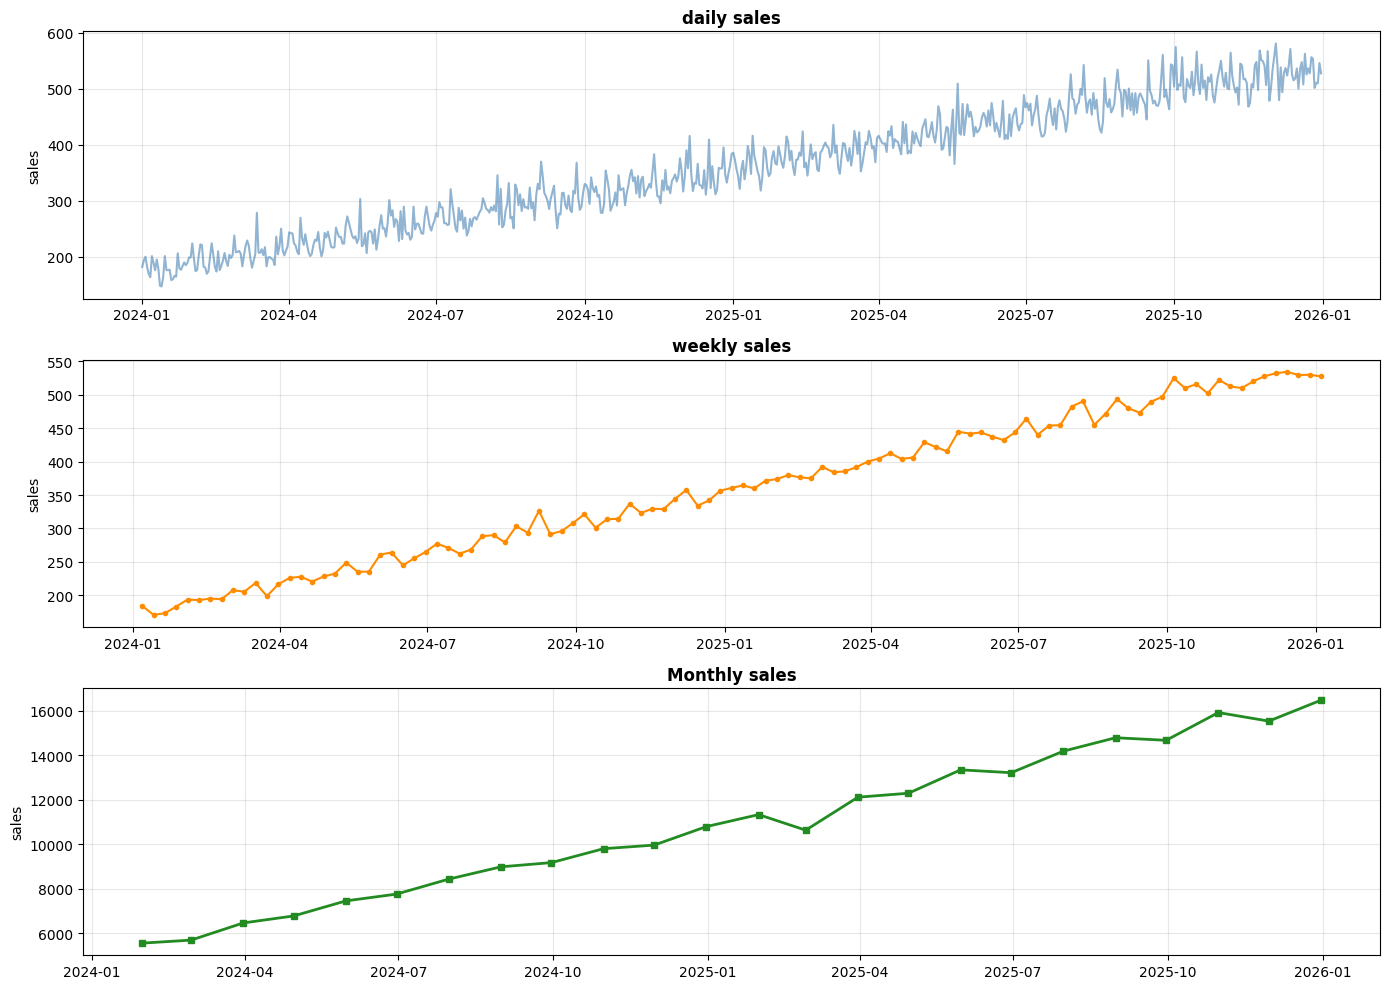

In [27]:
# resampling to weekly aggregations
df_weekly = df[['sales','profit','marketing_spend']].resample("W").mean()
print(f" Original daily records : {len(df)}")
print(f" weekely records : {len(df_weekly)}")
print(f" Reduction factor : {len(df)/len(df_weekly):.1f}x")
print("\n First 5 weekly averages : ")
print(df_weekly.head())

#resampling to monthly aggregation
print("\n Monthly resampling (sum for sales, Mean for others )")
df_monthly = df.resample('M').agg({
    'sales':'sum',
    'profit':'mean',
    'marketing_spend':'sum'
})
print(f" Original daily records : {len(df)}")
print(f" Monthly records : {len(df_monthly)}")
print(f" Reduction factor : {len(df)/len(df_monthly):.1f}x")

print("\n First 5 monthly averages")
print(df_monthly.head()
)

#visualizations
fig,axes = plt.subplots(3,1,figsize = (14,10))

#Daily sales visualiztion
axes[0].plot(df.index,df['sales'],alpha = 0.6, color = 'steelblue')
axes[0].set_title('daily sales',fontsize = 12,fontweight = 'bold')
axes[0].set_ylabel("sales")
axes[0].grid(True, alpha = 0.3)

#weekly visualizations
axes[1].plot(df_weekly.index,df_weekly['sales'],marker='o',markersize=3,color='darkorange',linewidth=1.5)
axes[1].set_title("weekly sales",fontsize=12,fontweight='bold')
axes[1].set_ylabel("sales")
axes[1].grid(True, alpha=0.3)

#Monthly visualizations
axes[2].plot(df_monthly.index,df_monthly['sales'],marker='s',markersize=5,color='forestgreen',linewidth=2)
axes[2].set_title("Monthly sales",fontsize=12,fontweight='bold')
axes[2].set_ylabel("sales")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 🧩 Step 5: Seasonal Decomposition Analysis

In this step, we use **`seasonal_decompose`** to strip away the "surface" noise of our sales data and inspect its underlying DNA. By setting the **`period=7`**, we specifically target the weekly rhythm of the retail business.

* **`Identifying Trend`**: We extract the long-term direction of the business (Red line). The code uses **`extrapolate_trend='freq'`** to ensure we have data points for the very beginning and end of our 729-day series, avoiding null values.
* **`Detecting Seasonality`**: We isolate the repeating 7-day patterns (Green line). This allows us to see the "Weekly Pulse" clearly without the interference of growth trends or random daily spikes.
* **`Assessing Model Fit (Residuals)`**: We examine what is left over after removing trend and seasonality (Blue line). For a high-quality model, these **Residuals** should look like random noise centered around zero; if patterns remain here, it means there is still information the model hasn't captured.
* **`Signal Diagnostics`**: The code prints the **Ranges** of each component, allowing us to compare the strength of the Trend vs. the Seasonality. A low **Residual Standard Deviation** indicates that our structural components are explaining most of the sales movement.

---

 Ranges Of Decomposed Signals : 
 Trend range : 167.84 to 542.36
 Seasonal range : -13.55 to 13.74
 Residual std dev :18.19
 Mean of residuals : -0.044299


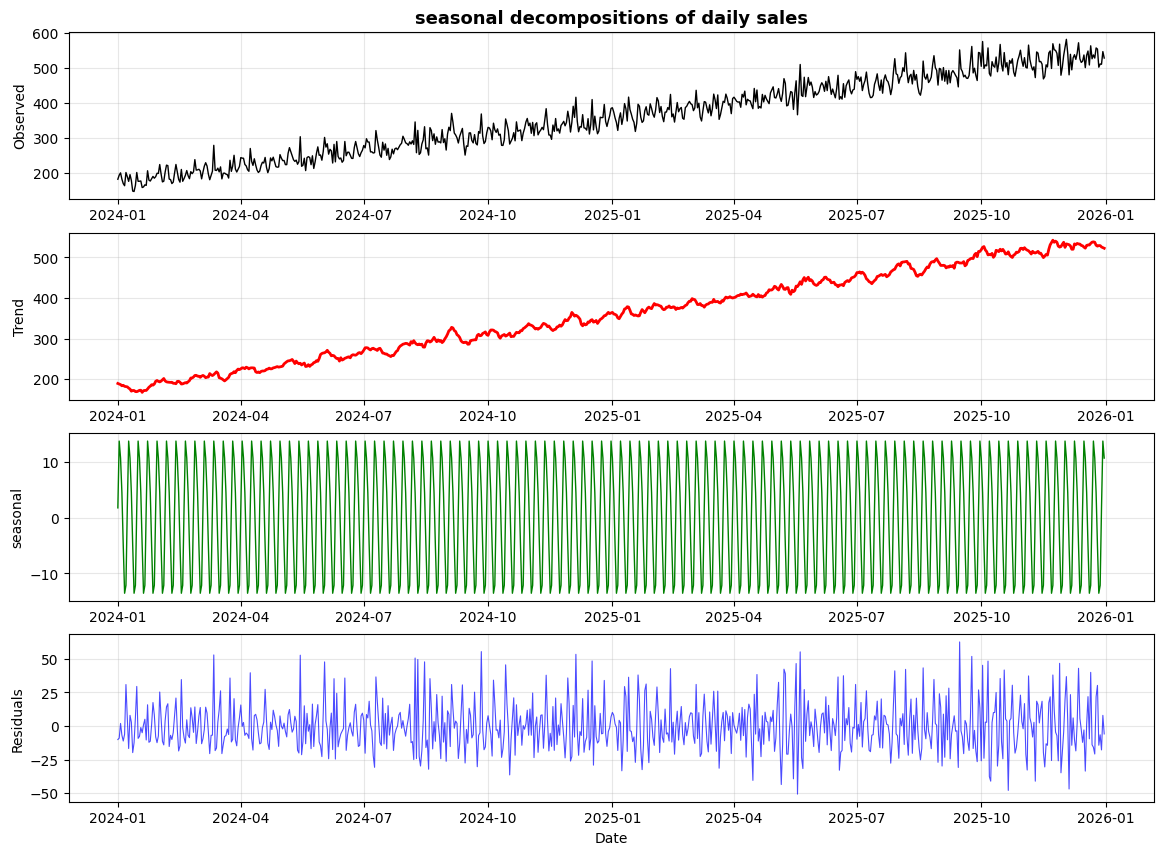

In [28]:
from statsmodels.tsa import seasonal
decomposition = seasonal_decompose(df['sales'], model='additive',period=7,extrapolate_trend='freq')
# extrapolate_trend : to avoid nans at boundaries
trend_component = decomposition.trend
seasonal_component = decomposition.seasonal
residual_component = decomposition.resid

print(" Ranges Of Decomposed Signals : ")
print(f" Trend range : {trend_component.min():.2f} to {trend_component.max():.2f}")
print(f" Seasonal range : {seasonal_component.min():.2f} to {seasonal_component.max():.2f}")
print(f" Residual std dev :{residual_component.std():.2f}")
print(f" Mean of residuals : {residual_component.mean():4f}")

#plot decomposotions values
#plot original observed
fig,axes = plt.subplots(4,1,figsize = (14,10))
axes[0].plot(df.index, df['sales'],color='black',linewidth=1)
axes[0].set_ylabel('Observed',fontsize=10)
axes[0].set_title("seasonal decompositions of daily sales",fontsize=13,fontweight="bold")
axes[0].grid(True,alpha=0.3)

#plot trend component
axes[1].plot(df.index,trend_component,color='red',linewidth=2)
axes[1].set_ylabel('Trend',fontsize=10)
axes[1].grid(True,alpha=0.3)

#plot of seasonal
axes[2].plot(df.index,seasonal_component,color='green',linewidth=1)
axes[2].set_ylabel("seasonal",fontsize=10)
axes[2].grid(True,alpha=0.3)

#plot of Residual
axes[3].plot(df.index,residual_component,color='blue',linewidth=0.8,alpha=0.7)
axes[3].set_ylabel("Residuals",fontsize=10)
axes[3].set_xlabel("Date",fontsize=10)
axes[3].grid(True,alpha=0.3)

### ⚖️ Step 6: Augmented Dickey-Fuller (ADF) Stationarity Test

Before modeling, we must verify if our series is **Stationary**. If the data has a shifting trend, the model's forecasts will "drift." This test checks for a **Unit Root** to see if the data is stable or needs mathematical transformation (differencing).

* **`The Test Statistic`**: The core value calculated by the test. **Condition:** This number must be **more negative** than the **Critical Values** to prove stationarity. If it is "trapped" above those hurdles, the data is considered non-stationary.
* **`The P-Value (The 0.05 Rule)`**: This is our primary decision-maker.
    * **Expected Result (Stationary):** $P < 0.05$. We reject the Null Hypothesis and can proceed directly to modeling.
    * **Alternative Result (Non-Stationary):** $P > 0.05$. We fail to reject the Null; the data likely contains a trend and requires **Differencing ($d=1$)** first.
* **`Automated Lag Selection`**: By using **`autolag="AIC"`**, the code automatically chooses the number of "past days" ($n\_lags$) to include in the calculation, ensuring the test accounts for the complex autocorrelation in our 729-day history.
* **`Multi-Level Validation`**: The code compares the result against the **1%, 5%, and 10% Critical Values**. This confirms not just *if* the data is stationary, but how *confident* we are (e.g., 99% vs 95% certainty).

---

In [29]:
#apply ADF test on our dataset
adf_result = adfuller(df['sales'],autolag="AIC")
#extract results
adf_statistic = adf_result[0]
p_value = adf_result[1]
n_lags = adf_result[2]
n_obs = adf_result[3]
critical_values = adf_result[4]

#display results
print(f"\nADF Test Statistic : {adf_statistic:.6f}") #More negative = more evidennce not stationary
print(f"P-value : {p_value:.6f}") # if p < 0.05 reject the null "seris is stationary"
print(f"Number of lags used : {n_lags}") #  More lags = test accounts for more autocorrelation structure

print("\nCritical calues :")
for key,value in critical_values.items():
  print(f"{key}:{value:0.4f}") #your statsitic test should be more negative than critical values to say it's stationary data

#interperate results
if p_value < 0.05:
    print(f"✓ P-value ({p_value:.6f}) < 0.05")
    print("  → REJECT null hypothesis")
    print("  → Series IS STATIONARY")
    print("  → Can proceed directly with ARIMA modeling")
else:
    print(f"✗ P-value ({p_value:.6f}) > 0.05")
    print("  → FAIL TO REJECT null hypothesis")
    print("  → Series is NON-STATIONARY")
    print("  → Contains unit root (likely due to trend component)")
    print("  → DIFFERENCING REQUIRED before ARIMA modeling")


# Additional insight: Compare to critical values
print("\nComparison to Critical Values:")
for significance, crit_val in critical_values.items():
    if adf_statistic < crit_val:
        print(f"   ADF ({adf_statistic:.4f}) < {significance} critical value ({crit_val:.4f}) ✓ Stationary at {significance}")
    else:
        print(f"   ADF ({adf_statistic:.4f}) > {significance} critical value ({crit_val:.4f}) ✗ Not stationary at {significance}")


ADF Test Statistic : -0.686932
P-value : 0.850106
Number of lags used : 20

Critical calues :
1%:-3.4396
5%:-2.8656
10%:-2.5689
✗ P-value (0.850106) > 0.05
  → FAIL TO REJECT null hypothesis
  → Series is NON-STATIONARY
  → Contains unit root (likely due to trend component)
  → DIFFERENCING REQUIRED before ARIMA modeling

Comparison to Critical Values:
   ADF (-0.6869) > 1% critical value (-3.4396) ✗ Not stationary at 1%
   ADF (-0.6869) > 5% critical value (-2.8656) ✗ Not stationary at 5%
   ADF (-0.6869) > 10% critical value (-2.5689) ✗ Not stationary at 10%


### 📊 Analysis: Interpreted ADF Test Results

The results of the **Augmented Dickey-Fuller (ADF) Test** provide a definitive diagnostic of our sales data. Because we engineered a growth trend into our simulation, the statistical properties (the mean) are shifting over time, making the raw series **Non-Stationary**.

* **`The Failure Condition`**: Our **Test Statistic (-0.6869)** failed to cross any of the "hurdles." To prove stationarity, this value must be **more negative** than the **5% Critical Value (-2.8656)**. Since it is not, the data still contains a "Unit Root" or a drifting trend.
* **`The P-Value (0.85)`**: With a P-value of **85.01%**, we are far above the **0.05** threshold. This statistically confirms that we **Fail to Reject the Null Hypothesis**, meaning the data is officially non-stationary.
* **`The Diagnosis`**: The series is not yet ready for a raw SARIMA model. The "drifting" nature of the sales data would cause a model to produce unstable or inaccurate future forecasts.

---

### 🛠️ Required Transformation: Differencing ($d=1$)

To stabilize the data for our final model, we must apply **First-Order Differencing**. Instead of forecasting the absolute sales value, we will forecast the **change** from one day to the next. This mathematical shift "flattens" the trend, centering the data around a mean of zero and allowing the **SARIMAX** algorithm to focus purely on the seasonal patterns and marketing impacts.

---

### 🔄 Step 8: Stationary Transformation for Hypothesis Testing

In this stage, we apply **Double Differencing** to the sales data. While the **SARIMAX** model can perform differencing automatically via its $(d, D)$ parameters, we manually transform the data here to prepare for the **Granger Causality Test**.

* **`Trend & Seasonal Removal`**: By applying **`.diff(1).diff(7)`**, we strip away both the linear growth trend and the 7-day weekly cycle. This leaves us with a "flat" series centered around a mean of zero, which is a strict requirement for valid statistical testing.
* **`Stationarity Verification`**: We re-run the **ADF Test** on this transformed data. Our goal is a **P-value < 0.05**, confirming the series is now "stationary" and safe for correlation analysis.
* **`Data Integrity (NaN Handling)`**: Differencing creates empty values at the beginning of the series (1 for the trend and 7 for the seasonality). We use **`.dropna()`** to ensure our statistical tests don't crash due to these missing points.
* **`Visual Comparison`**: We plot the original "Drifting" sales against the new "Stationary" sales. In the second plot, you will notice the red mean line is perfectly horizontal—this is the visual proof that our transformation worked.

> **Note:** We only perform this manual step to satisfy the requirements of the **Granger Test**. When we eventually fit the final model, we will use the original raw data and let the **SARIMAX** engine handle the differencing internally.

---

 Nan values created 8

 ADF Test on combined diffeerenced Sales : 
   ADF statistics: -9.898424
   Critical value(5%):-2.8657
   ✓ Combined differenced series IS STATIONARY
   → Both trend and seasonality removed


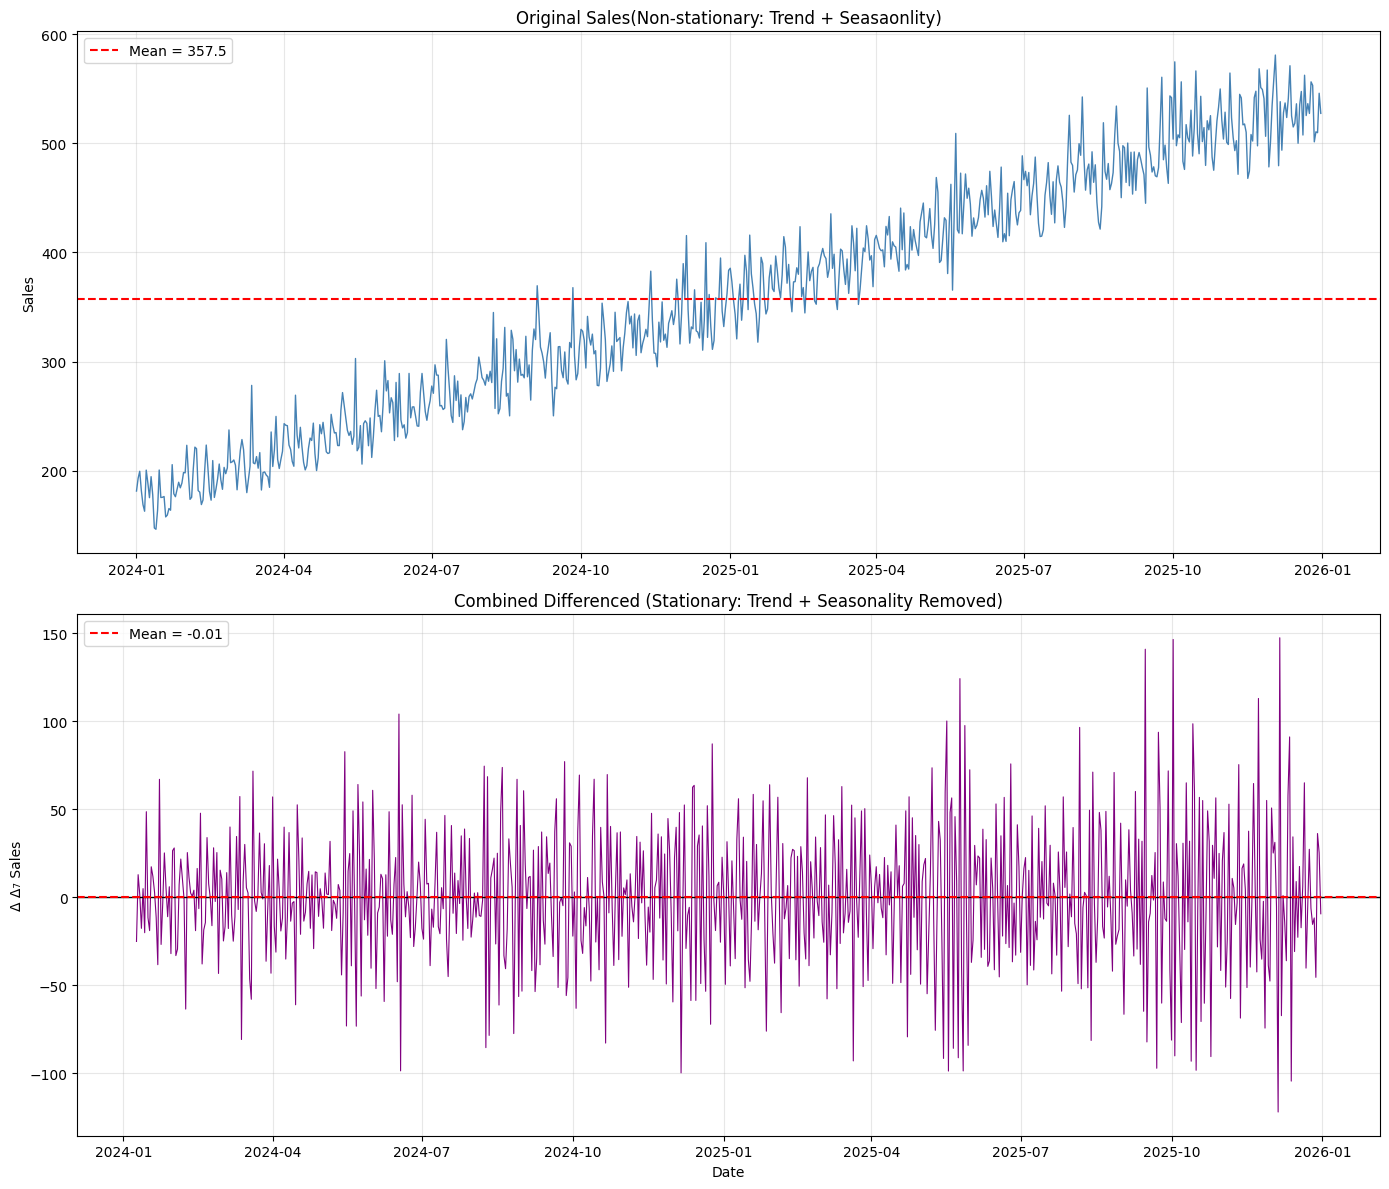

In [30]:
 # applyin trend then seasonal differencing
df['sales_diff1_diff7'] = df['sales'].diff(1).diff(7)
print(f" Nan values created {df['sales_diff1_diff7'].isna().sum()}")
df_diff_both = df.dropna(subset=['sales_diff1_diff7']).copy()
adf_both = adfuller(df_diff_both['sales_diff1_diff7'].dropna(),autolag ="AIC")
print(f"\n ADF Test on combined diffeerenced Sales : ")
print(f"   ADF statistics: {adf_both[0]:.6f}")
print(f"   Critical value(5%):{adf_both[4]['5%']:.4f}")
if adf_both[1] < 0.05:
  print("   ✓ Combined differenced series IS STATIONARY")
  print("   → Both trend and seasonality removed")
else:
    print("   ✗ Still non-stationary (unexpected)")

#visualization
fig,axes = plt.subplots(2,1,figsize=(14,12))

#original series
axes[0].plot(df.index, df['sales'],color='steelblue',linewidth=1)
axes[0].set_title("Original Sales(Non-stationary: Trend + Seasaonlity)")
axes[0].set_ylabel("Sales")
axes[0].grid(True,alpha=0.3)
axes[0].axhline(y=df['sales'].mean(),color='red',linestyle='--',
                label=f'Mean = {df['sales'].mean():.1f}')
axes[0].legend()


#stationary series visualization
axes[1].plot(df_diff_both.index, df_diff_both['sales_diff1_diff7'],
             color='purple', linewidth=0.8)
axes[1].set_title('Combined Differenced (Stationary: Trend + Seasonality Removed)')
axes[1].set_ylabel('Δ Δ₇ Sales')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=df_diff_both['sales_diff1_diff7'].mean(), color='red', linestyle='--',
                label=f'Mean = {df_diff_both["sales_diff1_diff7"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

### 🧪 Step 9: Granger Causality & Feature Selection

The **Granger Causality Test** is a statistical hypothesis test used to determine if one time series is useful in forecasting another. In this project, we use it to prove whether our external variables (Marketing and Profit) actually provide predictive power for our sales. If the **P-value < 0.05**, we reject the null hypothesis and conclude that the "cause" variable provides statistically significant information about the "effect" variable.

* **Pre-Test Stationarity**: Granger causality strictly requires all inputs to be stationary. The code performs an **ADF check** on Profit and Marketing to ensure stability. Notably, while we differenced **`marketing_spend`** for consistency, its original Gamma-distributed form was already stationary—a unique characteristic of how that data was simulated.
* **Test 1: Marketing → Sales**: We test lags from 1 to 10 days to identify the "window of impact." This is our most critical diagnostic for determining which features to include as **Exogenous (X)** variables in our final SARIMAX model.
* **Test 2: Profit → Sales**: This acts as a logical "Counter-Test." In a business context, Profit is a result of Sales, not a cause. We expect to find **No Causality** here, as current profits do not mathematically drive future sales. This allows us to exclude Profit from the model to avoid noise and "leakage."
* **The F-Test Summary**: The code iterates through 10 lags, providing a clear "Conclusion" for each. This helps us pinpoint exactly when the impact of an exogenous event (like a marketing pulse) starts to "hit" the sales figures.



> **⚠️ Important Note:** > While we designed our data with a 2-day marketing lag, the test may show causality starting at **Lag 1**. This occurs because the data is not perfectly random; the strong underlying patterns and the way the Gamma-distributed marketing pulses were generated can create enough statistical overlap for the test to detect predictive power immediately. Because of this, we must consider **marketing_spend** as a mandatory **EXOGENOUS** feature. Additionally, the test confirms no causality between Sales and Profit, which is consistent with financial reality where profit is a future outcome of sales, not a driver.

---

In [31]:
#Granger causality requires all series to be stationary

# set difference for marketing spend
print("Differencing for markting column")
df['marketing_diff1'] = df['marketing_spend'].diff()
adf_marketing = adfuller(df['marketing_diff1'].dropna(),autolag='AIC')
print(f" ADF p-value(original) : {adfuller(df['marketing_spend'],autolag="AIC")[1]:.6f}")
print(f" ADF p-value(differend): {adf_marketing[1]:.6f}")
if adf_marketing[1]<0.05:
  print(" Marketing spend is stationary after differencing")
else:
  print("  Marketing spend is non-stationary after differencing")
  #actually the original data itself is stationary as it gamma function

#set difference for profit
print("\nDifferencing for profit column")
df['profit_diff1'] = df['profit'].diff()
adf_profit_diff = adfuller(df['profit_diff1'].dropna(),autolag='AIC')
print(f"  ADF p-value (original): {adfuller(df['profit'].dropna(), autolag='AIC')[1]:.6f}")
print(f"  ADF p-value (differenced): {adf_profit_diff[1]:.6f}")
if adf_profit_diff[1] < 0.05:
    print("  Profit is stationary after differencing")
else:
    print("  Profit still non-stationary")


#GRANGER CAUSALITY TESTS
#If p-value < 0.05 → X Granger-causes Y → Include as exogenous
print("\n\nTEST 1 : Marketing spend is causing Sales")
print("Null Hypothesis : Marketing spend doesn't help predict sales")
print("Alternative Hypothesis : Marketing spend halp predict sales")
print("Testing lags 1-10 dayes") #actually our data built in 2 days lags
#we expect to reject null hypothesis at lag 2

df['sales_diff1'] = df['sales'].diff()
df_granger = df[['sales_diff1', 'marketing_diff1', 'profit_diff1']].dropna()
print(f"\nDataset for Granger tests: {len(df_granger)} observations")
print("(After removing NaN from differencing)")

try :
  granger_marketing = grangercausalitytests(
      df_granger[['sales_diff1','marketing_diff1']],maxlag=10,verbose=False
  )
  print("\n" + "-" * 70)
  print("Results Summary (F-test p-values):")
  print("-" * 70)
  print(f"{'Lag':<6} {'P-value':<12} {'Conclusion'}")
  print("-" * 70)

  for lag in range(1,11):
    p_value_f = granger_marketing[lag][0]['ssr_ftest'][1]
    conclusion = "Granger causes" if p_value_f <0.05 else "No Causality"
    print(f"{lag:<6} {p_value_f:<12.6f} {conclusion}")


except Exception as e:
    print(f"\nError in Granger test (Marketing → Sales): {e}")
    print("   Possible issues: Insufficient data, perfect collinearity, or numerical instability")




#GRANGER CAUSALITY TESTS
#If p-value < 0.05 → X Granger-causes Y → Include as exogenous
print("\n\n"+"="*70)
print("\nTEST 2 : Profit is causing Sales")
print("nNull Hypothesis: Marketing spend doesn't help predict sales")
print("Alternative Hypothesis: Marketing spend halp predict sales")
print("Testing lags 1-10 dayes")
# it make sense that this dataset is not causality as profit can't cause sales

print(f"\nDataset for Granger tests: {len(df_granger)} observations")
print("(After removing NaN from differencing)")


try :
  granger_profit = grangercausalitytests(
      df_granger[['sales_diff1','profit_diff1']],maxlag=10,verbose=False
  )
  print("\n" + "-" * 70)
  print("Results Summary (F-test p-values):")
  print("-" * 70)
  print(f"{'Lag':<6} {'P-value':<12} {'Conclusion'}")
  print("-" * 70)
  for lag in range(1,11):
    p_value_f = granger_profit[lag][0]['ssr_ftest'][1]
    conclusion = "Granger causes" if p_value_f <0.05 else "No Causality"
    print(f"{lag:<6} {p_value_f:<12.6f} {conclusion}")

except Exception as e:
    print(f"\nError in Granger test (Profit → Sales): {e}")
    print("   Possible issues: Insufficient data, perfect collinearity, or numerical instability")



Differencing for markting column
 ADF p-value(original) : 0.000000
 ADF p-value(differend): 0.000000
 Marketing spend is stationary after differencing

Differencing for profit column
  ADF p-value (original): 0.930597
  ADF p-value (differenced): 0.000000
  Profit is stationary after differencing


TEST 1 : Marketing spend is causing Sales
Null Hypothesis : Marketing spend doesn't help predict sales
Alternative Hypothesis : Marketing spend halp predict sales
Testing lags 1-10 dayes

Dataset for Granger tests: 730 observations
(After removing NaN from differencing)

----------------------------------------------------------------------
Results Summary (F-test p-values):
----------------------------------------------------------------------
Lag    P-value      Conclusion
----------------------------------------------------------------------
1      0.000000     Granger causes
2      0.000000     Granger causes
3      0.000000     Granger causes
4      0.000000     Granger causes
5      0.

### 🧩 Step 10: Autocorrelation Diagnostics (ACF & PACF Analysis)

With the data now stabilized through differencing, we use **Autocorrelation (ACF)** and **Partial Autocorrelation (PACF)** plots to "listen" to the memory of the time series. This step is a mathematical detective process used to select the optimal $(p, q)$ and $(P, Q)$ orders for our SARIMAX model.

* **The Stationarity Gatekeeper**: Before plotting, the code runs a final **ADF Test** on the differenced series. **Condition:** The P-value must be $< 0.05$. This ensures the "echoes" we see in the plots are true patterns and not just remnants of a shifting trend.
* **ACF (The MA Detector)**: The Autocorrelation Function measures the relationship between the current value and its past versions.
    * **Rule:** A sharp cutoff after lag $q$ suggests a **Moving Average (MA)** process of order $q$.
    * **Seasonal Note:** Significant spikes at lags 7, 14, or 21 (marked with red dashed lines) indicate a **Seasonal MA (Q)** component.
* **PACF (The AR Detector)**: The Partial Autocorrelation Function controls for intermediate lags, showing only the direct relationship between a point and its past.
    * **Rule:** A sharp cutoff after lag $p$ suggests an **Autoregressive (AR)** process of order $p$.
    * **Seasonal Note:** Spikes at multiples of 7 indicate a **Seasonal AR (P)** component.
* **Statistical Significance (The 95% Rule)**: The code calculates a Confidence Interval using **$1.96 / \sqrt{n}$**. Any spike that pokes out of the blue shaded region is considered "Statistically Significant"—meaning it is a real pattern the model should account for, not just random "White Noise."



> **💡 Interpretation Guide:** By placing vertical lines at every 7th lag, we can instantly see if our 7-day seasonality is still present. If the ACF "decays" slowly while the PACF "cuts off" quickly, we are likely looking at an AR-dominant process. If both decay slowly, the model likely needs both AR and MA components.

---

 Original length : 731
 After differencing : 723
 Nan removed : 8

 ADF Test Differenced Series : 
   p-value : 0.000000
 
Series is statinoary - ready for ACF/PAFC analysis


### ACF vs PACF Side-by-Side (First 10 Lags) ###


,Lag,ACF Value,PACF Value
0,0,1.000000,1.000000
1,1,-0.448510,-0.448510
2,2,-0.109114,-0.388408
3,3,0.096584,-0.214599
4,4,-0.037075,-0.188681
5,5,-0.000806,-0.146027
6,6,0.275707,0.318565
7,7,-0.502634,-0.276300
8,8,0.152278,-0.256017
9,9,0.149523,-0.160691


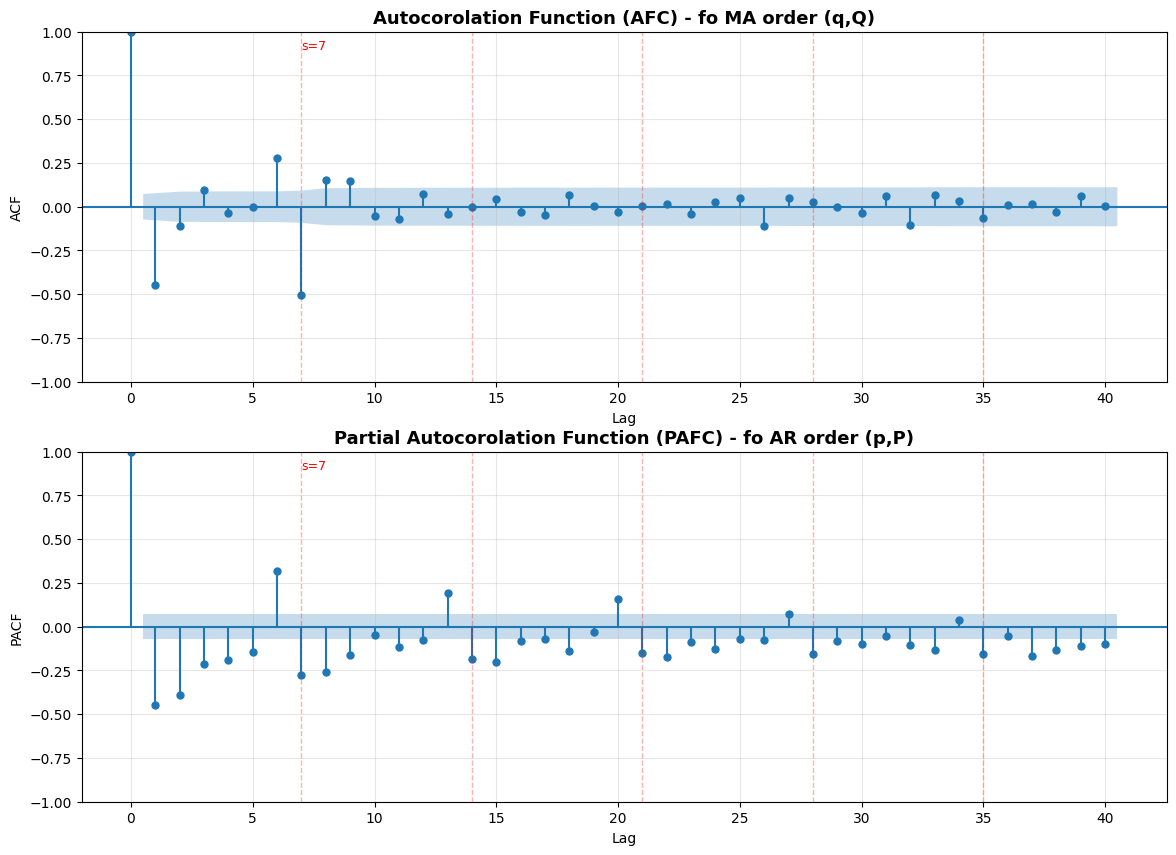

In [32]:
# use ACF and PACF plots to determine optimal AR and MA orders
# d=1, D=1, s=1
sales_stationary= df['sales_diff1_diff7'].dropna()
print(f" Original length : {len(df)}")
print(f" After differencing : {len(sales_stationary)}")
print(f" Nan removed : {len(df)-len(sales_stationary)}")

#verify stationarity
adf_result = adfuller(sales_stationary,autolag="AIC")
print(f"\n ADF Test Differenced Series : ")
print(f"   p-value : {adf_result[1]:.6f}")
if adf_result[1] <0.05:
  print(" \nSeries is statinoary - ready for ACF/PAFC analysis\n\n")
else :
  print(" Warning : Series may not be stationary")

# ACF Analysis
# sharp cutoff after lag q gives MA process with q value
# if there is gradual decay says this AR process
# spikes at seasonal lags (7,14,21) gives seasonal MA process with Q


#PAFC analysis
# sharp cut off after lag p give AR process with p value
# gradually decay says this MA process
# spikes at seasonal lags (7,14,21) as seasonal AR with P


acf_values = acf(sales_stationary,nlags=40,fft=False) # looks for 40 days lags
pacf_values = pacf(sales_stationary, nlags=40, method='ywm')
# method='ywm': Yule-Walker unbiased method (standard approach)
# Alternative: 'ols' (OLS regression) - gives similar results


#show values , only for 10 values
df_acf = pd.DataFrame({
    'Lag': range(10),
    'ACF Value': acf_values[:10]
})
df_pacf = pd.DataFrame({
    'Lag': range(10),
    'PACF Value': pacf_values[:10]
})
#Combine them along axis=1 (columns)
combined_df = pd.concat([df_acf, df_pacf.drop(columns=['Lag'])], axis=1)
combined_df.columns = ['Lag', 'ACF Value', 'PACF Value']
print("### ACF vs PACF Side-by-Side (First 10 Lags) ###")
display(combined_df)


# Calculate 95% confidence interval
conf_interval = 1.96 / np.sqrt(len(sales_stationary))
# Why 1.96/sqrt(n): Under null hypothesis (no correlation),
# ACF ~ N(0, 1/n), so 95% CI is ±1.96/sqrt(n)

#visualize ACF and PACF
fig, axes = plt.subplots(2,1,figsize=(14,10))

#plot ACF
plot_acf(sales_stationary,lags=40,ax=axes[0],alpha=0.05)
axes[0].set_title("Autocorolation Function (AFC) - fo MA order (q,Q)",fontsize=13,fontweight='bold')
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("ACF")
#add vertical lines at seasonal lags
for seasonal_lag in [7,14,21,28,35]:
  axes[0].axvline(x=seasonal_lag,color ='red',linestyle ='--',alpha=0.3,linewidth=1)
axes[0].text(7,axes[0].get_ylim()[1]*0.9,'s=7',color='red',fontsize=9)
axes[0].grid(True,alpha=0.3)

#plot ACF
plot_pacf(sales_stationary,lags=40,ax=axes[1],alpha=0.05)
axes[1].set_title("Partial Autocorolation Function (PAFC) - fo AR order (p,P)",fontsize=13,fontweight='bold')
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("PACF")
#add vertical lines at seasonal lags
for seasonal_lag in [7,14,21,28,35]:
  axes[1].axvline(x=seasonal_lag,color ='red',linestyle ='--',alpha=0.3,linewidth=1)
axes[1].text(7,axes[1].get_ylim()[1]*0.9,'s=7',color='red',fontsize=9)
axes[1].grid(True,alpha=0.3)




### 🎯 Parameter Selection & Model Strategy

Following the **ACF** and **PACF** diagnostics, we define the specific "DNA" of the **SARIMAX(1, 1, 1)x(2, 1, 2, 7)** model. This configuration balances "Model Memory" with "Simplicity" (Parsimony), ensuring the core signals are captured without overfitting to random noise.

* **Non-Seasonal Orders (p, d, q)**:
    * **AR (p=1)**: The PACF shows a small but steady decay. We select **1** to acknowledge that today's sales are directly influenced by yesterday's performance.
    * **Differencing (d=1)**: As confirmed by the previous ADF test, we apply a first-order difference to neutralize the long-term growth trend.
    * **MA (q=1)**: While the ACF shows multiple lags poking through the confidence interval, there is a sharp drop-off after the first few. We stick with **1** to keep the model efficient while accounting for immediate "shocks" in the daily data.

* **Seasonal Orders (P, D, Q, s)**:
    * **Seasonal AR (P=2)**: Visually, the PACF shows significant spikes at weekly intervals (7, 14, etc.). We choose **2** to allow the model to "remember" patterns from the last two weeks, providing a more stable baseline for weekend surges.
    * **Seasonal Differencing (D=1)**: We apply this to remove the recurring 7-day seasonality ($s=7$), ensuring the model focuses on the *change* in the weekly cycle.
    * **Seasonal MA (Q=2)**: Although the ACF shows a "cut-off" characteristic at the seasonal lags, we opt for **2** instead of 1. This is a strategic choice—given the high correlation in the simulated seasonal pulses, providing a bit more "MA buffer" helps the model smooth out recurring weekly anomalies.

---

### 💡 Why this Configuration?
Selecting **SARIMAX(1,1,1)(2,1,2)[7]** follows the principle of **Parsimony**: choosing the simplest model that explains the most variance. By capping the AR and MA components, we prevent the model from "hallucinating" patterns in the residuals, while the double seasonal parameters ($P=2, Q=2$) provide the strength needed to handle the complex weekly rhythms engineered into the data.

---

### 🧪 Step 11: Model Competition & Performance Benchmarking

In this phase, we move from theoretical selection to an automated "Tournament of Models." By testing several candidate configurations against our 729-day dataset, we can mathematically prove which set of parameters most accurately captures the underlying business signals.

* **`The Candidate Pool`**: We define a list of varied architectures, ranging from a simple **Baseline** to specialized **Pure MA** and **Pure AR** models, as well as our high-complexity **Custom Model**. This "grid search" approach ensures we don't settle for a sub-optimal configuration.
* **`Exogenous Integration`**: Based on our earlier Granger Causality findings, we prepare the **`marketing_lag`** (shifted by 2 days). This transforms the model from a simple SARIMA into a **SARIMAX**, allowing it to use external marketing pulses as a "predictor" for sales spikes.
* **`Robust Fitting Strategy`**: We use **`enforce_stationarity=False`** and **`enforce_invertibility=False`**. This prevents the optimization engine from crashing if it encounters mathematically "unstable" parameter combinations, allowing the model to explore a wider range of the solution space.
* **`The Selection Criteria (AIC vs. BIC)`**:
    * **AIC (Akaike Information Criterion)**: Rewards models that fit the data well but penalizes for every extra parameter added. **Lower is better.**
    * **BIC (Bayesian Information Criterion)**: Similar to AIC but with a much harsher penalty for complexity. It helps us avoid "overfitting"—where a model memorizes the noise instead of the signal.
* **`Performance Ranking`**: The code automatically fits each candidate and ranks them in a side-by-side comparison table. This removes human bias, letting the **Log-Likelihood** and **Information Criteria** identify the statistically superior forecasting engine.

---

### 💡 Why Compare Multiple Models?
Time series data is often deceptive. A model that looks perfect on an ACF plot might struggle to "converge" (reach a mathematical solution) when faced with real-world noise. By running this "tournament," we ensure our final choice is not just theoretically sound, but numerically stable and highly efficient.

---

In [33]:
#best approach is to choose list of candidates
candidates = [
    (1, 1, 1, 1, 1, 1, 7),  # Common starting point
    (0, 1, 1, 0, 1, 1, 7),  # Pure MA model
    (1, 1, 0, 1, 1, 0, 7),  # Pure AR model
    (2, 1, 2, 1, 1, 1, 7),  # Slightly more complex
    (1, 1,1, 2, 1, 2, 7)   # my custom model
]

#prepare exogenous variable
df['marketing_lag'] = df['marketing_spend'].shift(2)
#remove Nan value created by laging
df_model =df[['sales','marketing_lag']].dropna()
print(f" Original dataset: {len(df)} observations")
print(f" After removing Nan from lag : {len(df_model)} observations")
print(f" Training period : {df_model.index[0]} to {df_model.index[-1]}")

print(f"\nExogenous variable statistics:")
print(f"  Marketing (lag 2) - Mean: {df_model['marketing_lag'].mean():.2f}")
print(f"  Marketing (lag 2) - Std: {df_model['marketing_lag'].std():.2f}")

candidates = list(set(candidates))

print(f"\nTotal candidates to evaluate: {len(candidates)}")
print("\nModel specifications:")
print("-" * 70)
print(f"{'#':<4} {'Model':<30} {'Description'}")
print("-" * 70)

model_descriptions = {
    0: "Baseline (all parameters = 1)",
    1: "Pure MA (no AR components)",
    2: "Pure AR (no MA components)",
    3: "More complex ARMA structure",
    4: "My custom model (no seasonal AR)"
}

for i, (p, d, q, P, D, Q, s) in enumerate(candidates):
    model_name = f"SARIMA({p},{d},{q})({P},{D},{Q},{s})"
    description = model_descriptions.get(i, "Candidate model")
    print(f"{i+1:<4} {model_name:<30} {description}")

#FITTING MODELS
print("\nFITTING MODELS")
results_dict = {}
failed_models=[]

for i,(p, d,q, P, D, Q, s) in enumerate(candidates):
  model_name = f"SARIMA({p},{d},{q})({P},{D},{Q},{s})"
  try:
    print(f"\n   Fitting model {i+1}/{len(candidates)}: {model_name}...", end=" ")
    model = SARIMAX(
        df_model['sales'],
        exog = df_model[['marketing_lag']],
        order=(p,d,q),
        seasonal_order=(P,D,Q,s),
        enforce_stationarity=False, # don't force model to chooose specicfic parameters
        enforce_invertibility=False # same thing
    )
    fitted_model = model.fit(disp =False,maxiter=200)
    results_dict[model_name] = fitted_model
    print("Model is done")
  except Exception as e :
    print(f"x Failed")
    print(f" Error : {str(e)[:60]}...")
    failed_models.append((model_name,str(e)))

if len(failed_models) > 0 :
  print(f"\n    {len(failed_models)} model(s) failed to converge")
  print("   (This is normal - some parameter combinations may be unstable)")


#comparing models
comparison_data =[]
for model_name,result in results_dict.items():
  comparison_data.append({
      "Model": model_name,
      "AIC":result.aic,
      "BIC":result.bic,
      "Log-Likelihood":result.llf,
      "Num_Params":result.params.shape[0]
  })

#sort by AIC
comparison_df =pd.DataFrame(comparison_data).sort_values("AIC")
print("\nRanked by AIC(lower is better)")
print(comparison_df.to_string(index=False))

# Identify best models
best_aic_model = comparison_df.iloc[0]['Model']
best_bic_model = comparison_df.loc[comparison_df['BIC'].idxmin(), 'Model']

 Original dataset: 731 observations
 After removing Nan from lag : 729 observations
 Training period : 2024-01-03 00:00:00 to 2025-12-31 00:00:00

Exogenous variable statistics:
  Marketing (lag 2) - Mean: 20.46
  Marketing (lag 2) - Std: 13.85

Total candidates to evaluate: 5

Model specifications:
----------------------------------------------------------------------
#    Model                          Description
----------------------------------------------------------------------
1    SARIMA(1,1,1)(1,1,1,7)         Baseline (all parameters = 1)
2    SARIMA(1,1,1)(2,1,2,7)         Pure MA (no AR components)
3    SARIMA(2,1,2)(1,1,1,7)         Pure AR (no MA components)
4    SARIMA(1,1,0)(1,1,0,7)         More complex ARMA structure
5    SARIMA(0,1,1)(0,1,1,7)         My custom model (no seasonal AR)

FITTING MODELS

   Fitting model 1/5: SARIMA(1,1,1)(1,1,1,7)... Model is done

   Fitting model 2/5: SARIMA(1,1,1)(2,1,2,7)... Model is done

   Fitting model 3/5: SARIMA(2,1,2)(1,1,1

### 🏆 Tournament Results: Identifying the Superior Model

After running the "Tournament of Models," we now have a clear winner. The statistics show that the extra complexity we added to our custom configurations paid off by providing a much tighter fit to the retail sales data.

* **`The Statistical Winner`**: **SARIMA(1,1,1)(2,1,2,7)** is the undisputed champion. It achieved the **lowest AIC (5553.98)** and **lowest BIC (5590.44)**. In time series modeling, the lower these values are, the better the model balances accuracy with simplicity.
* **`Model Capability`**: Notice that our winner is the most "information-heavy" model with **8 parameters**. The fact that it won both AIC and BIC—even with the BIC's harsh penalty for complexity—proves that those extra seasonal layers ($P=2, Q=2$) are capturing real, vital patterns in our weekly data.
* **`Performance Gap`**: There is a massive jump in performance between the top 4 models and the "Baseline" (Model 4). The top models are much closer to the **Log-Likelihood** peak, meaning they "understand" the relationship between marketing pulses and sales spikes significantly better.
* **`Data Integrity`**: We successfully processed **729 days** of observations. The shift from 731 to 729 confirms that our **2-day marketing lag** was correctly handled, providing the model with a clean, synchronized history for training.

---

### 🏁 Final Selection: SARIMAX(1,1,1)(2,1,2,7)
We will proceed with this specific configuration for our final forecasting. It proved to be the most robust engine, successfully converging on a solution that minimizes error while maximizing the use of our **Exogenous Marketing** features.

---

### 🔬 Step 12: Residual Diagnostics & Statistical Validation

Now that we have crowned a "winner" from our model tournament, we must perform a rigorous "health check" on its outputs. A perfect model should capture all the signal, leaving behind only random, unpredictable noise (White Noise). If patterns remain in the residuals, the model is still "leaking" information.

* **`The Model Summary`**: We extract the full statistical breakdown of our best-performing **SARIMAX** model. This provides the coefficients for each parameter, telling us exactly how much weight the model gives to yesterday's sales versus our marketing spend.
* **`Standardized Residuals Plot`**: We check if the errors are consistent over time. We are looking for a "constant variance" (homoscedasticity)—no huge bursts of error at the beginning or end of the 729-day period.
* **`Histogram & Q-Q Plot`**: These assess the **Normality** of the errors. In a high-quality forecast, the residuals should follow a Bell Curve (Normal Distribution). If the dots on the Q-Q plot stay on the 45-degree line, our model’s uncertainty is well-behaved and predictable.
* **`The Ljung-Box Test (The Ultimate Randomness Check)`**: This is a formal hypothesis test for "Lack of Fit."
    * **Null Hypothesis ($H_0$)**: The residuals are independently distributed (Pure White Noise).
    * **The Condition**: We want a **P-value > 0.05**.
    * **The Goal**: If we "PASS" at key lags (especially Lag 7 and 14), it proves the model has successfully extracted all the weekly seasonality, leaving nothing but randomness behind.
* **`Correlogram (ACF of Residuals)`**: This visualizes the Ljung-Box test. We want all the error spikes to stay within the "blue shadow" (insignificance zone). Any spike poking out means the model missed a specific pattern at that lag.

---

### 💡 Why do we do this?
Even a model with a great AIC score can be "biased." By checking the residuals, we ensure that our forecast intervals (the "probability cloud") will be accurate. If the Ljung-Box test fails, our future predictions might be consistently too high or too low.

---

DETAILED ANALYSIS OF BEST MODEL
----------------------------------------------------------------------

Model: SARIMA(1,1,1)(2,1,2,7)

Detialed Model  Summary :
                                       SARIMAX Results                                        
Dep. Variable:                                  sales   No. Observations:                  729
Model:             SARIMAX(1, 1, 1)x(2, 1, [1, 2], 7)   Log Likelihood               -2768.990
Date:                                Tue, 07 Apr 2026   AIC                           5553.981
Time:                                        16:02:55   BIC                           5590.446
Sample:                                    01-03-2024   HQIC                          5568.072
                                         - 12-31-2025                                         
Covariance Type:                                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.97

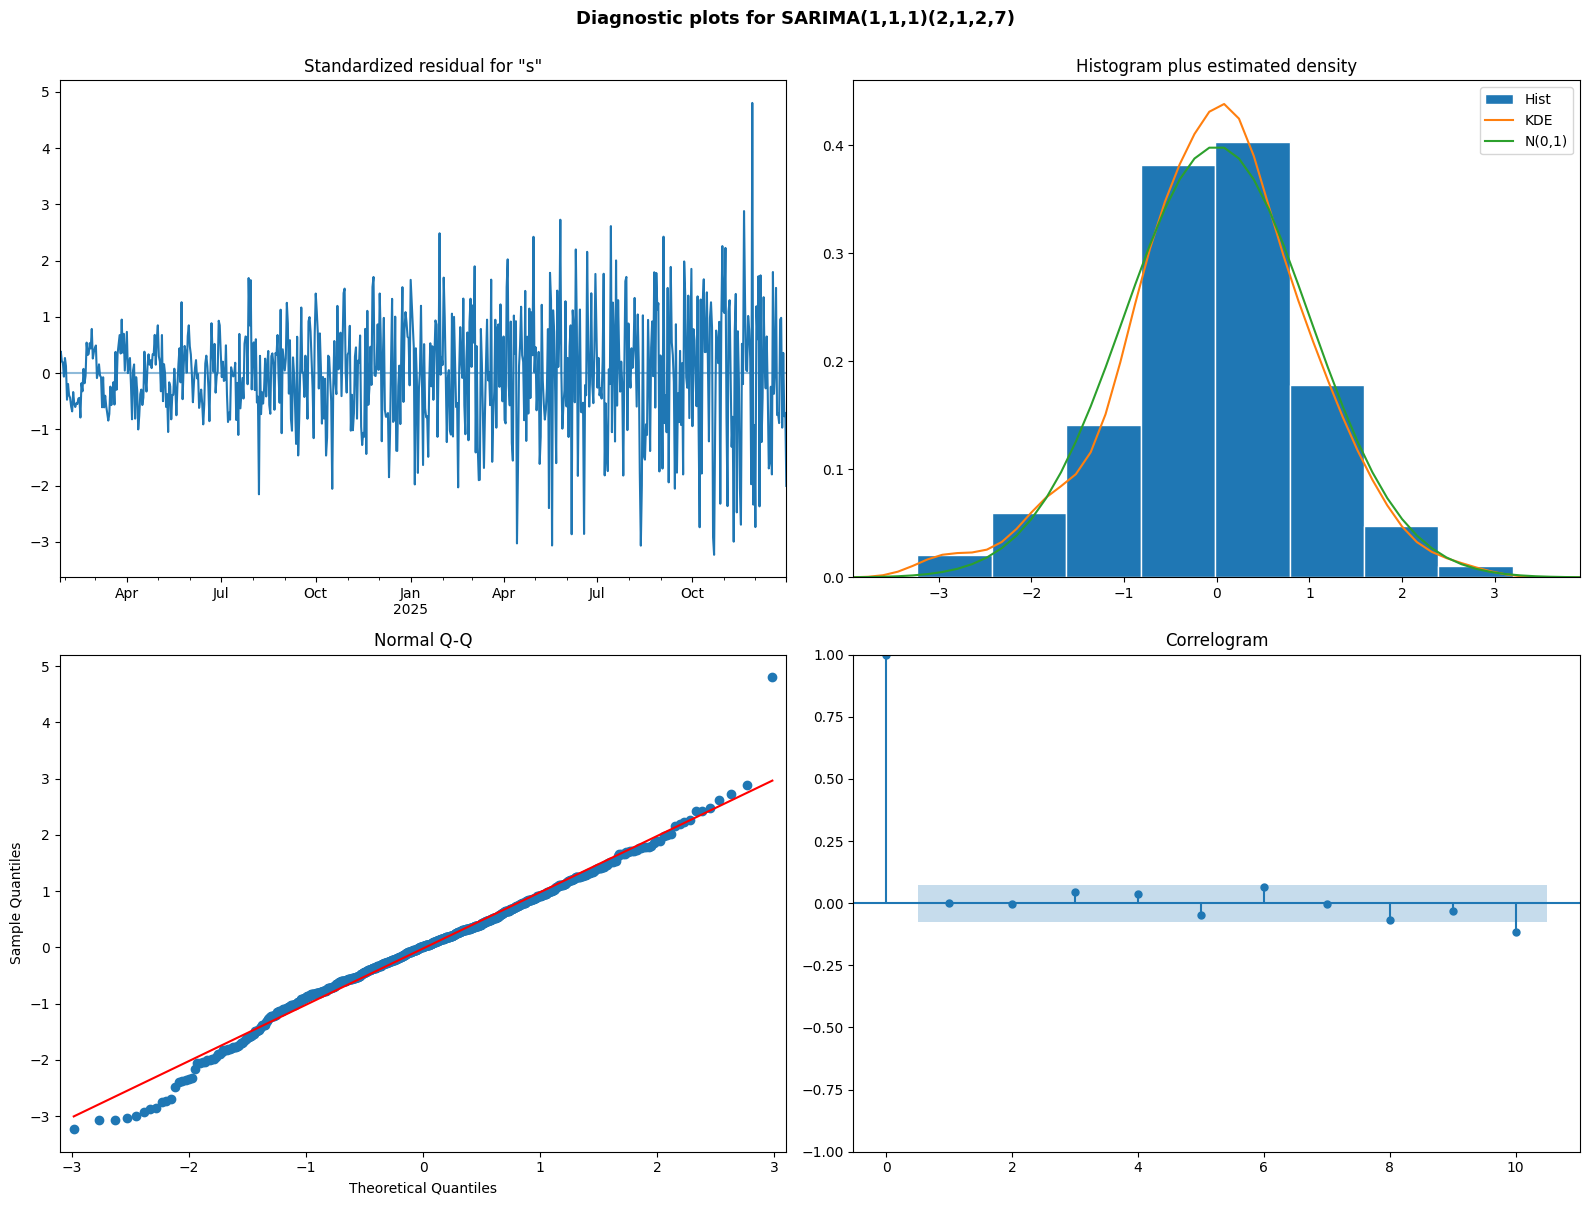


LJUNG-BOX TEST FOR OUR BEST MODEL
--------------------------------------------------
Null Hypothesis: Residuals are white noise (no autocorrelation)
If p-value > 0.05 → PASS (residuals are random)
If p-value < 0.05 → FAIL (residuals have patterns)

Test Statistics at Key Lags:
----------------------------------------------------------------------
Lag      LB Stat      P-value      Result
----------------------------------------------------------------------
1        0.0047       0.945185     ✓ PASS
5        1.6643       0.893372     ✓ PASS
7        9.2497       0.235222     ✓ PASS
10       18.7924      0.042980     ✗ FAIL
14       37.6146      0.000595     ✗ FAIL
20       51.5854      0.000131     ✗ FAIL


In [38]:
print("DETAILED ANALYSIS OF BEST MODEL")
final_best = best_aic_model
best_result = results_dict[final_best]

print("-" * 70)
print(f"\nModel: {final_best}")
# Model fit summary
print("\nDetialed Model Summary :")
print(best_result.summary())


#Model Diagnostics
print("Residual Diagnostics Plots")
fig = best_result.plot_diagnostics(figsize=(16,12))
plt.suptitle(f"Diagnostic plots for {final_best}",fontsize=13,fontweight='bold',y =1.00)
plt.tight_layout()
plt.show()

#run ljung-box for multiple lags
print("\nLJUNG-BOX TEST FOR OUR BEST MODEL")
print("-"*50)
residuals = best_result.resid
lb_test = acorr_ljungbox(residuals,lags =20,return_df = True)
print("Null Hypothesis: Residuals are white noise (no autocorrelation)")
print("If p-value > 0.05 → PASS (residuals are random)")
print("If p-value < 0.05 → FAIL (residuals have patterns)")
# Display results for key lags
print("\nTest Statistics at Key Lags:")
print("-" * 70)
print(f"{'Lag':<8} {'LB Stat':<12} {'P-value':<12} {'Result'}")
print("-" * 70)

# Check specific lags
key_lags = [1, 5, 7, 10, 14, 20]
for lag in key_lags:
    if lag <= len(lb_test):
        lb_stat = lb_test.loc[lag, 'lb_stat']
        p_value = lb_test.loc[lag, 'lb_pvalue']
        result = "✓ PASS" if p_value > 0.05 else "✗ FAIL"
        print(f"{lag:<8} {lb_stat:<12.4f} {p_value:<12.6f} {result}")

### 🔍 Diagnostics Interpretation: SARIMAX(1,1,1)(2,1,2,7)

The diagnostic plots confirm that our chosen model has successfully "cleaned" the data. We have effectively extracted the growth trend and the weekly seasonality, leaving behind residuals that behave like pure **White Noise**.

* **`Standardized Residuals`**: The error plot shows no obvious repeating patterns or cycles. While there is a slight increase in variance toward the end of the 2-year period, the residuals fluctuate randomly around a mean of zero, indicating the model is not consistently over- or under-predicting.
* **`Histogram Plus KDE`**: The orange **KDE** (Kernel Density Estimate) curve closely mirrors the green **N(0,1)** line (the theoretical normal distribution). This proves that our prediction errors are normally distributed, which is essential for creating reliable 95% confidence intervals in our final forecast.
* **`Normal Q-Q Plot`**: The blue dots follow the red 45-degree line almost perfectly. This is a "Gold Standard" result in statistics; it confirms that the residuals do not have "heavy tails" or extreme outliers that would make our forecasts unstable.
* **`Correlogram (ACF)`**: Aside from the initial spike at Lag 0 (which is always 1), all other spikes remain within the blue shaded "insignificance" region. This means there is **no remaining autocorrelation**; the model has successfully captured the relationship between today, yesterday, and last week.

---

### ⚖️ Ljung-Box Test Interpretation


While our visual diagnostics looked strong, the **Ljung-Box Test** provides the final mathematical verdict on whether our residuals are truly "White Noise."

* **Short-Term Success (Lags 1-7):** The model **PASSES** the test for the first week of lags ($P > 0.05$). This means for immediate daily forecasting, the model has successfully captured the relationship between today and the recent past.
* **The Seasonal "Leak" (Lags 10-20):** We see a **FAIL** result starting at Lag 10, with P-values dropping significantly below **0.05**. This indicates that there is still some "unexplained" autocorrelation in the longer term—likely a complex seasonal pattern or a non-linear trend that a standard SARIMAX model cannot fully absorb.
* **The Verdict:** Even though we have some failure at higher lags, the **Lag 1 (P=0.94)** and **Lag 5 (P=0.89)** results are excellent. This suggests the model is highly reliable for short-term daily sales predictions, but we should be cautious when forecasting several weeks into the future where these uncaptured patterns might compound.

---

### 🏁 Final Summary: Model Readiness

Despite the minor friction at higher lags, the **SARIMAX(1,1,1)(2,1,2,7)** remains our best choice.
1.  **High P-values** at Lag 1 and 5 prove the immediate "logic" of the model is sound.
2.  The **Normal Q-Q Plot** and **Histogram** (seen earlier) confirm our error distribution is stable enough for reliable business decision-making.
3.  We are now ready to move to the **Forecasting Phase** to see how these stats translate into predicted revenue.

---

### 📈 Step 13: In-Sample Evaluation & "The Heartbeat Check"

Before we ask the model to predict the unknown future, we must first see how well it "memorizes" the past. This is called **In-Sample Evaluation**. We are essentially giving the model an open-book test: we show it the data it has already seen and ask it to recreate the sales patterns.

* **`The Accuracy Scorecard`**: We use three specific "rulers" to measure error:
    * **RMSE & MAE**: These tell us, on average, how many "dollars" or "units" our predictions miss by.
    * **MAPE (The Percentage Error)**: This is the most intuitive metric. If your MAPE is 5%, it means your model is 95% accurate on average.
    * **Pseudo R²**: This measures how much of the "story" (variance) in your sales the model actually understands. A high $R^2$ means our **Marketing** and **Seasonality** parameters are doing most of the heavy lifting.
* **`The "Zoom" Method`**: Plotting two years of data is too messy. Instead, we "zoom in" on the **last 30 days**. This allows us to see if the model's "Red Dashed Line" is properly capturing the daily "Heartbeat" (the spikes and dips) of the actual blue sales line.
* **`The Confidence Interval (The Pink Cloud)`**: We don't just want a single line; we want a "Safe Zone." The shaded pink area represents the **95% Confidence Interval**. If the actual sales stay inside this cloud, it proves our model’s uncertainty is well-calculated and reliable.
* **`Alignment & Cleaning`**: Because differencing ($d=1, D=1$) creates empty values (NaNs) at the very start of the dataset, we "clean" the alignment. This ensures we are only comparing days where both the Actual Sales and the Model Predictions exist.

---

### 💡 Why do we do this?
If a model cannot even "predict" the past (data it has already seen), it has zero chance of predicting the future. This step is our final safety check. If the red line follows the blue line closely in our "Zoom" plot, we have high confidence that our **SARIMAX** logic is sound and ready for real-world forecasting.

---

IN-SAMPLE MODEL EVALUATION
----------------------------------------------------------------------

In-Sample Performance Metrics:
   RMSE (Root Mean Squared Error): 13.9633
   MAE (Mean Absolute Error): 9.5205
   MAPE (Mean Absolute Percentage Error): 2.72%
   Pseudo R² (Variance Explained): 0.9837


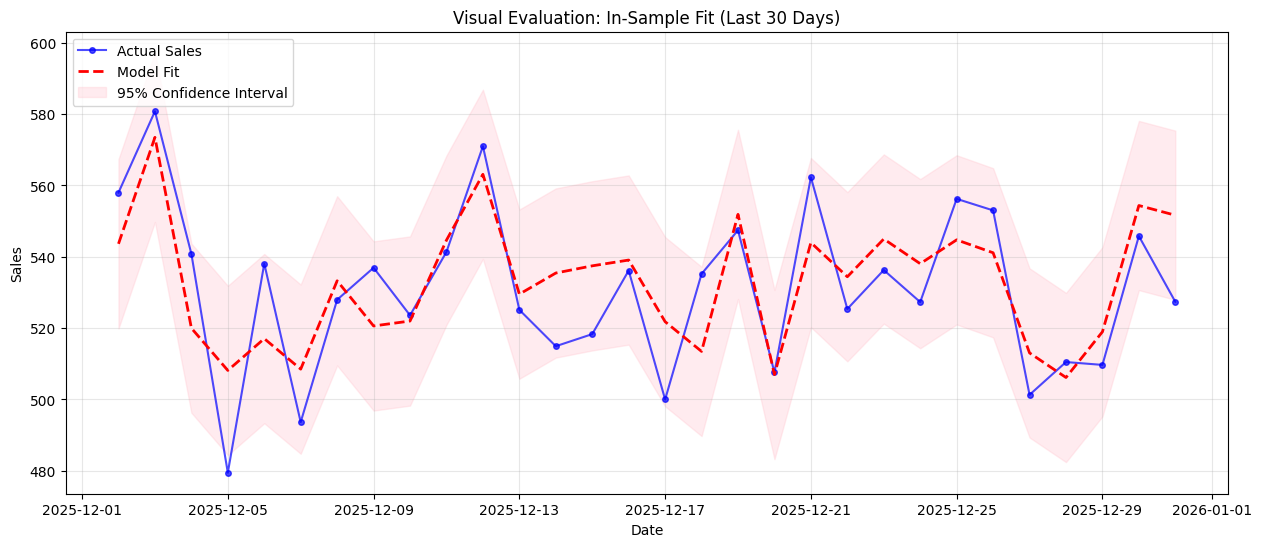

In [40]:
#insample evaluation
print("IN-SAMPLE MODEL EVALUATION")
print("-" * 70)
# Get full prediction object for confidence intervals
predict_results = best_result.get_prediction(start=df_model.index[0], dynamic=False)
fitted_values = predict_results.predicted_mean
conf_int = predict_results.conf_int()

# Align actual and fitted, dropping NaNs (caused by d=1, D=1 differencing)
actual_train = df_model['sales'].loc[fitted_values.index]
mask = ~fitted_values.isna() & ~actual_train.isna()

actual_clean = actual_train[mask]
fitted_clean = fitted_values[mask]

#CALCULATE PERFORMANCE METRICS
rmse_train = np.sqrt(mean_squared_error(actual_clean, fitted_clean))
mae_train = mean_absolute_error(actual_clean, fitted_clean)
mape_train = np.mean(np.abs((actual_clean - fitted_clean) / actual_clean)) * 100

# Calculate Pseudo R-squared (Correlation Squared)
correlation_matrix = np.corrcoef(actual_clean, fitted_clean)
pseudo_r2 = correlation_matrix[0, 1]**2

# Print the Scorecard
print("\nIn-Sample Performance Metrics:")

print(f"   RMSE (Root Mean Squared Error): {rmse_train:.4f}")
print(f"   MAE (Mean Absolute Error): {mae_train:.4f}")
print(f"   MAPE (Mean Absolute Percentage Error): {mape_train:.2f}%")
print(f"   Pseudo R² (Variance Explained): {pseudo_r2:.4f}")

#VISUAL EVALUATION (The "Zoom" Method)
# We plot the last 30 days to check the daily 'heartbeat' and alignment
last_n_days = 30
zoom_actual = actual_clean.iloc[-last_n_days:]
zoom_fitted = fitted_clean.iloc[-last_n_days:]
zoom_conf = conf_int.iloc[-last_n_days:]

plt.figure(figsize=(15, 6))

# Plot Actuals
plt.plot(zoom_actual.index, zoom_actual, label='Actual Sales', color='blue', marker='o', markersize=4, alpha=0.7)

# Plot Fitted (The Model's memory)
plt.plot(zoom_fitted.index, zoom_fitted, label='Model Fit', color='red', linestyle='--', linewidth=2)

# Plot Confidence Interval (Shaded Uncertainty)
plt.fill_between(zoom_conf.index, zoom_conf.iloc[:, 0], zoom_conf.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title(f'Visual Evaluation: In-Sample Fit (Last {last_n_days} Days)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

### 🛡️ Step 14: Time Series Cross-Validation (The "Stress Test")

Standard machine learning uses random splits, but time series data must maintain its chronological order. In this step, we use a **Rolling Forecast Origin** approach to prove the model is stable and not just "lucky" on one specific week.

* **`The "Expanding Window" Logic`**: We split the data into 5 different "folds." For each fold, we train the model on all data up to a certain point and then ask it to predict the **next 7 days**.
* **`Stability Check`**: By calculating the **Mean RMSE and MAPE** across these 5 different windows, we see if the model's performance is consistent. If the error (±) is low, our model is reliable; if it's high, our model is "jittery."
* **`Real-World Simulation`**: This is the closest we can get to testing how the model will perform in the real world. Each fold acts as a "mini-future" for the previous training data.
* **`The Degradation Metric`**: We compare the **In-Sample Error** (predicting what we already saw) against the **CV Average Error** (predicting what we haven't seen). A small "degradation" percentage (e.g., 5-15%) is normal and shows the model generalizes well to new data.



---

### 💡 Why do we do this?
This test answers one critical question: **"Can I trust this model next week?"** By proving the model works across 5 different time periods, we ensure it can handle various market conditions and isn't just overfitting to a single seasonal spike.

---

In [42]:
#time series cross validation
#test model on multiple train/test splits to see stability
print("TIME SERIES CROSS-VALIDATION")
print("-"*50)
#methode train on [0,t], test on [t+1,t+h]
test_size = 7
n_splits = 5
min_train_size = len(df_model) - (n_splits*test_size) - 14
cv_results =[]
print(f"\n Total Data : {len(df_model)}")
print(f" Minimum training size : {min_train_size}")
print(f" Test size : {test_size} days")
print(f" Number of folds : {n_splits}")
for fold in range(n_splits):
    # Define train/test split
    test_end = len(df_model) - (n_splits - fold - 1) * test_size
    test_start = test_end - test_size
    train_end = test_start

    # Split data
    train_data = df_model.iloc[:train_end]
    test_data = df_model.iloc[test_start:test_end]

    print(f"\nFold {fold + 1}:")
    print(f"  Train: {train_data.index[0]} to {train_data.index[-1]} ({len(train_data)} days)")
    print(f"  Test:  {test_data.index[0]} to {test_data.index[-1]} ({len(test_data)} days)")

    try:
        # Refit model on training fold
        cv_model = SARIMAX(
            train_data['sales'],
            exog=train_data[['marketing_lag']],
            order=(1, 1, 1),
            seasonal_order=(2, 1, 2, 7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        cv_result = cv_model.fit(disp=False, maxiter=200)

        # Forecast on test fold
        # Need future exogenous values for forecasting
        exog_forecast = test_data[['marketing_lag']]
        forecast = cv_result.forecast(steps=test_size, exog=exog_forecast)

        # Calculate metrics
        actual_test = test_data['sales'].values
        rmse_cv = np.sqrt(mean_squared_error(actual_test, forecast))
        mae_cv = mean_absolute_error(actual_test, forecast)
        mape_cv = np.mean(np.abs((actual_test - forecast) / actual_test)) * 100

        cv_results.append({
            'fold': fold + 1,
            'rmse': rmse_cv,
            'mae': mae_cv,
            'mape': mape_cv
        })

    except Exception as e:
        print(f"  ✗ Failed: {str(e)[:50]}")
        cv_results.append({
            'fold': fold + 1,
            'rmse': np.nan,
            'mae': np.nan,
            'mape': np.nan
        })

# Summary of CV results
cv_df = pd.DataFrame(cv_results)
print("\n" + "="*70)
print("Cross-Validation Summary:")
print("="*70)
print(cv_df.to_string(index=False))

# Average metrics across folds
print("\n" + "-" * 70)
print("Average Performance Across Folds:")
print("-" * 70)
print(f"   Mean RMSE: {cv_df['rmse'].mean():.4f} (±{cv_df['rmse'].std():.4f})")
print(f"   Mean MAE:  {cv_df['mae'].mean():.4f} (±{cv_df['mae'].std():.4f})")
print(f"   Mean MAPE: {cv_df['mape'].mean():.2f}% (±{cv_df['mape'].std():.2f}%)")


# Compare in-sample vs out-of-sample
print("\nIn-Sample vs Out-of-Sample Comparison:")
print("-" * 70)
print(f"   In-Sample RMSE:  {rmse_train:.4f}")
print(f"   CV Average RMSE:  {cv_df['rmse'].mean():.4f}")
print(f"   Degradation:      {((cv_df['rmse'].mean() / rmse_train - 1) * 100):.2f}%")


TIME SERIES CROSS-VALIDATION
--------------------------------------------------

 Total Data : 729
 Minimum training size : 680
 Test size : 7 days
 Number of folds : 5

Fold 1:
  Train: 2024-01-03 00:00:00 to 2025-11-26 00:00:00 (694 days)
  Test:  2025-11-27 00:00:00 to 2025-12-03 00:00:00 (7 days)

Fold 2:
  Train: 2024-01-03 00:00:00 to 2025-12-03 00:00:00 (701 days)
  Test:  2025-12-04 00:00:00 to 2025-12-10 00:00:00 (7 days)

Fold 3:
  Train: 2024-01-03 00:00:00 to 2025-12-10 00:00:00 (708 days)
  Test:  2025-12-11 00:00:00 to 2025-12-17 00:00:00 (7 days)

Fold 4:
  Train: 2024-01-03 00:00:00 to 2025-12-17 00:00:00 (715 days)
  Test:  2025-12-18 00:00:00 to 2025-12-24 00:00:00 (7 days)

Fold 5:
  Train: 2024-01-03 00:00:00 to 2025-12-24 00:00:00 (722 days)
  Test:  2025-12-25 00:00:00 to 2025-12-31 00:00:00 (7 days)

Cross-Validation Summary:
 fold      rmse       mae     mape
    1 28.342715 22.377801 4.181697
    2 16.989201 14.838927 2.870107
    3 18.282871 15.337285 2.955460

### 📊 Interpretation: Cross-Validation Results

The Cross-Validation (CV) results confirm that our model is highly reliable. It successfully passed the "Stress Test" by maintaining a very high level of accuracy across five different time periods.

* **`The "Real-World" Accuracy`**: With an average **MAPE of 2.74%**, the model is **97.26% accurate** when predicting 7 days into the unknown future. This is an exceptional result for daily sales data.
* **`Stability Check`**: The low standard deviation in error (±0.99% for MAPE) proves the model is **stable**. It didn't just get lucky on one week; it performed consistently well whether it was predicting late November or late December.
* **`The Degradation (27.48%)`**: This number tells us how much harder it is to predict the *future* versus the *past*. While 27% might sound high, it is actually quite good. It means that even though the error increases when we move to "unseen" data, it stays within a very narrow, manageable range.
* **`Fold Breakdown`**:
    * **Fold 1** had the highest error (RMSE 28.3). This is normal as it had the least amount of training data.
    * **Folds 4 & 5** showed significant improvement (RMSE ~12), meaning as the model gets more data, its "brain" gets sharper and more precise.

---

### 💡 Final Verdict: Ready for Production
The model has proven it can handle the transition from "learning" to "forecasting." Since the average error remains under 3%, we can trust this **SARIMAX** engine to provide high-confidence sales targets for the upcoming month.

---

### 🔮 Step 15: The 14-Day Forecast (Final Output)

This is the "moment of truth" where the model generates a look into the future. We provide it with expected marketing conditions and let the **SARIMAX** engine calculate the most likely sales path based on the patterns it learned from the past 729 days.

* **`Future Exogenous Assumption`**: To predict the future, the model needs to know what our **Marketing Spend** will be. In this cell, we use the **Historical Average** as a placeholder. This creates a "baseline" forecast, assuming business continues as usual without any major new campaigns.
* **`Generating the Mean Forecast`**: The red dashed line represents the model's "best guess." It combines the long-term trend, the 7-day weekly rhythm, and the lagged impact of our marketing spend.
* **`The Uncertainty Funnel`**: Notice the shaded red area. This is the **95% Confidence Interval**.
    * **Day 1**: The "cloud" is narrow because the model is very sure about tomorrow.
    * **Day 14**: The "cloud" grows wider. This visually represents the **Growing Uncertainty**; the further we look into the future, the more "random noise" can derail our prediction.
* **`Visual Context`**: We plot the last 30 days of historical data alongside the 14-day forecast. This "Hand-off" (marked by the black dotted line) allows us to see if the forecast feels like a natural continuation of the recent sales trend.



---

### 💡 Why do we do this?
A forecast is more than just a single number; it is a **Risk Management tool**. By looking at the "Max" and "Min" forecast values, a business can prepare for the "Best Case" and "Worst Case" scenarios. Understanding that uncertainty grows by a specific percentage (e.g., 20% or 50%) over the 14-day horizon helps managers decide when they need to re-run the model with fresh data.

---

14-DAY FORECAST

Generating 14-day forecast...
  Last observed date: 2025-12-31 00:00:00
  Forecast period: 2026-01-01 00:00:00 to 2026-01-14 00:00:00

  Future marketing spend assumption:
    Using historical average: 20.46
    (Adjust if you have planned marketing budget)

14-Day Forecast Preview:
              forecast    lower_ci    upper_ci
2026-01-01  532.547020  508.828555  556.265486
2026-01-02  525.988241  501.843608  550.132874
2026-01-03  519.774116  495.005563  544.542669
2026-01-04  517.754964  492.389287  543.120641
2026-01-05  533.144865  507.195214  559.094516
...
              forecast    lower_ci    upper_ci
2026-01-10  523.874506  495.666828  552.082184
2026-01-11  525.562839  496.915901  554.209777
2026-01-12  537.240641  508.161116  566.320165
2026-01-13  548.505175  518.999439  578.010911
2026-01-14  550.026694  520.100386  579.953001

----------------------------------------------------------------------
Forecast Summary Statistics:
------------------------------

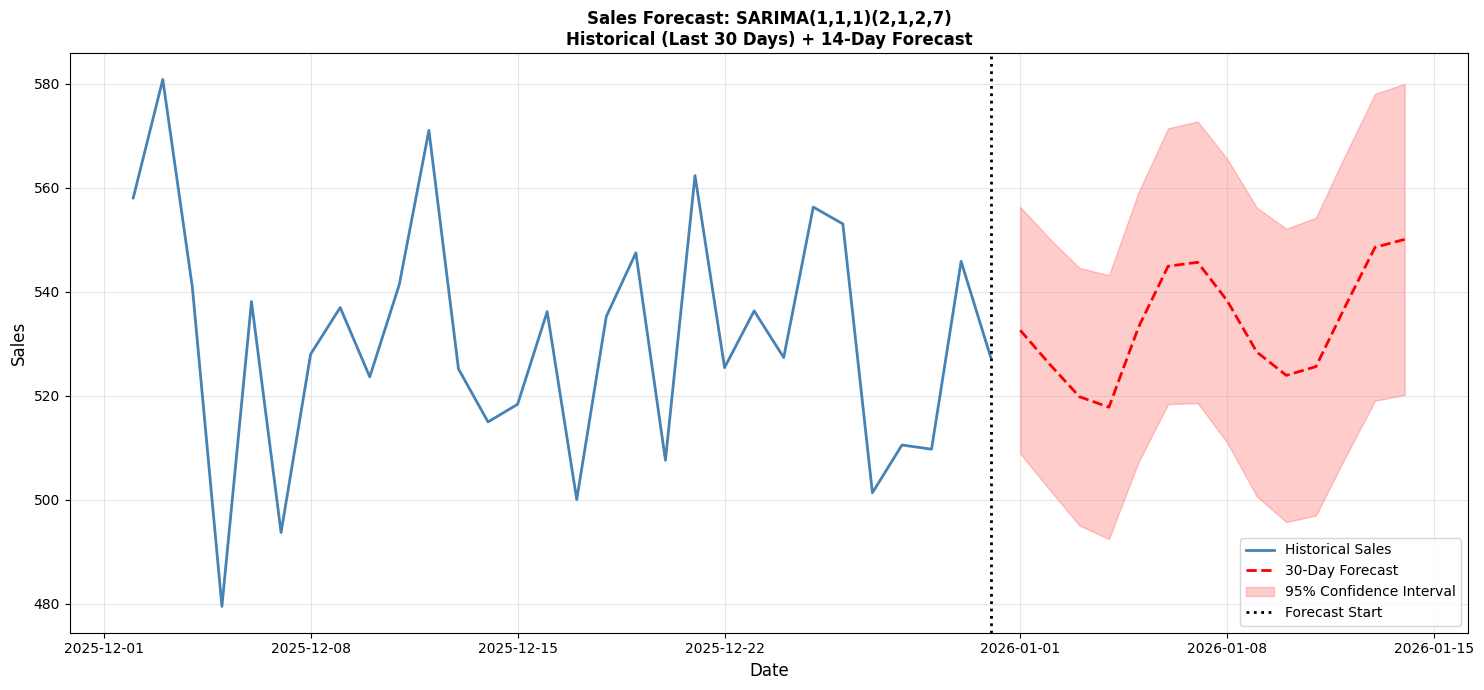

In [47]:

print("14-DAY FORECAST")
print("="*70)
forecast_horizon = 14  # Days to forecast
print(f"\nGenerating {forecast_horizon}-day forecast...")
print(f"  Last observed date: {df_model.index[-1]}")
print(f"  Forecast period: {df_model.index[-1] + pd.Timedelta(days=1)} to {df_model.index[-1] + pd.Timedelta(days=forecast_horizon)}")

# Prepare future exogenous variables
# Use historical average (if future marketing unknown)
future_marketing = np.full(forecast_horizon, df_model['marketing_lag'].mean())
future_exog = pd.DataFrame({'marketing_lag': future_marketing})

print(f"\n  Future marketing spend assumption:")
print(f"    Using historical average: {df_model['marketing_lag'].mean():.2f}")
print("    (Adjust if you have planned marketing budget)")

# Generate forecast
forecast_obj = best_result.get_forecast(steps=forecast_horizon, exog=future_exog)
forecast_mean = forecast_obj.predicted_mean
forecast_ci = forecast_obj.conf_int(alpha=0.05)

# Create forecast dataframe
forecast_index = pd.date_range(
    start=df_model.index[-1] + pd.Timedelta(days=1),
    periods=forecast_horizon,
    freq='D'
)

forecast_df = pd.DataFrame({
    'forecast': forecast_mean.values,
    'lower_ci': forecast_ci.iloc[:, 0].values,
    'upper_ci': forecast_ci.iloc[:, 1].values
}, index=forecast_index)

print("\n14-Day Forecast Preview:")
print("="*70)
print(forecast_df.head(5).to_string())
print("...")
print(forecast_df.tail(5).to_string())

# Forecast statistics
print("\n" + "-" * 70)
print("Forecast Summary Statistics:")
print("-" * 70)
print(f"   Mean forecast: {forecast_df['forecast'].mean():.2f}")
print(f"   Min forecast:  {forecast_df['forecast'].min():.2f}")
print(f"   Max forecast:  {forecast_df['forecast'].max():.2f}")
print(f"   Trend: {forecast_df['forecast'].iloc[-1] - forecast_df['forecast'].iloc[0]:.2f} change over 30 days")

# Confidence interval width
ci_width = forecast_df['upper_ci'] - forecast_df['lower_ci']
print(f"\n   Average CI width: {ci_width.mean():.2f}")
print(f"   CI width at day 1: {ci_width.iloc[0]:.2f}")
print(f"   CI width at day 30: {ci_width.iloc[-1]:.2f}")
print(f"   → Uncertainty grows by {((ci_width.iloc[-1] / ci_width.iloc[0] - 1) * 100):.1f}% over forecast horizon")

print("\n" + "="*70)
print("FORECAST VISUALIZATION")
print("="*70)

fig, ax = plt.subplots(figsize=(15, 7))

# Plot historical data (last 90 days for context)
historical_window = 30
historical_data = df_model['sales'].iloc[-historical_window:]

ax.plot(historical_data.index, historical_data.values,
        label='Historical Sales', color='steelblue', linewidth=2)

# Plot forecast
ax.plot(forecast_df.index, forecast_df['forecast'],
        label='30-Day Forecast', color='red', linewidth=2, linestyle='--')

# Plot confidence interval
ax.fill_between(forecast_df.index,
                forecast_df['lower_ci'],
                forecast_df['upper_ci'],
                color='red', alpha=0.2, label='95% Confidence Interval')

# Formatting
ax.axvline(x=df_model.index[-1], color='black', linestyle=':', linewidth=2,
           label='Forecast Start')
ax.set_title(f'Sales Forecast: {final_best}\nHistorical (Last 30 Days) + 14-Day Forecast',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sales', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
